# **Student Pass/Fail Data - EDA and Preprocessing Pipelines**

**Introducción**

---


En este notebook se realizará un analisis exploratorio de datos sobre el dataset "Student Pass/Fail", seguidamente se hara un preprocesamiento de pipelines para caracteristicas numericas y categoricas.

El dataset tiene información sobre el rendimiento de estudiantes de una clase, incluyendo si pasaron la clase o no. El objetivo es predecir si los estudiantes pasaran la clase o no. Por lo que es un problema de clasificación binaria. La fuente de este dataset es Kaggle: https://www.kaggle.com/datasets/ishanjha100/student-passfail-data


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PowerTransformer
from sklearn.compose import ColumnTransformer

In [2]:
data = pd.read_csv('../data/Pass-Fail Data.csv')
data

,student_id,attendance_pct,homework_pct,midterm_score,study_hours_per_week,pass
0,1,95,92,88,12,1
1,2,88,85,79,10,1
2,3,60,55,58,4,0
3,4,72,70,65,6,1
4,5,40,45,50,3,0
...,...,...,...,...,...,...
95,96,89,92,94,14,1
96,97,79,77,75,8,1
97,98,55,56,58,5,0
98,99,91,90,88,12,1


# **Información Básica y Estadisticas**

Se hace uso de .info() para obtener la información general del dataset, incluyendo el número de entradas no nulas y los tipos de datos de cada columna.

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   student_id            100 non-null    int64
 1   attendance_pct        100 non-null    int64
 2   homework_pct          100 non-null    int64
 3   midterm_score         100 non-null    int64
 4   study_hours_per_week  100 non-null    int64
 5   pass                  100 non-null    int64
dtypes: int64(6)
memory usage: 4.8 KB


Con .describe() se obtiene un resumen estadistico de las columnas del dataset.

In [4]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
student_id,100.0,50.50,29.011492,1.0,25.75,50.5,75.25,100.0
attendance_pct,100.0,69.52,17.651783,30.0,55.00,72.5,85.00,95.0
homework_pct,100.0,69.03,17.013040,35.0,55.00,70.0,85.00,96.0
midterm_score,100.0,68.78,14.717254,42.0,56.00,68.0,82.00,97.0
study_hours_per_week,100.0,7.28,3.621150,2.0,4.00,7.0,10.00,15.0
pass,100.0,0.60,0.492366,0.0,0.00,1.0,1.00,1.0


En total hay 6 columnas:
1. student_id: Número de estudiante.
2. attendance_pct: Porcentaje de asistencia.
3. homework_pct: Calificación de tareas.
4. midterm_score: Calificación de examen.
5. study_hours_per_week: Horas estudiadas.
6. pass: Aprobo o fallo.

En el analisis se ignorara la columna "student_id" debido a que solo sirve para identificar a un alumno de otro. Todas son de tipo int64.

# **Visualización de Características Numéricas**

El siguiente paso es visualizar la distribución de las características numéricas del dataset. La columna "pass" es un valor numérico, pero se utiliza para clasificar, por lo que no se usará en este análisis.

Se crean histogramas con estimación de densidad de kernel para cada columna numérica.

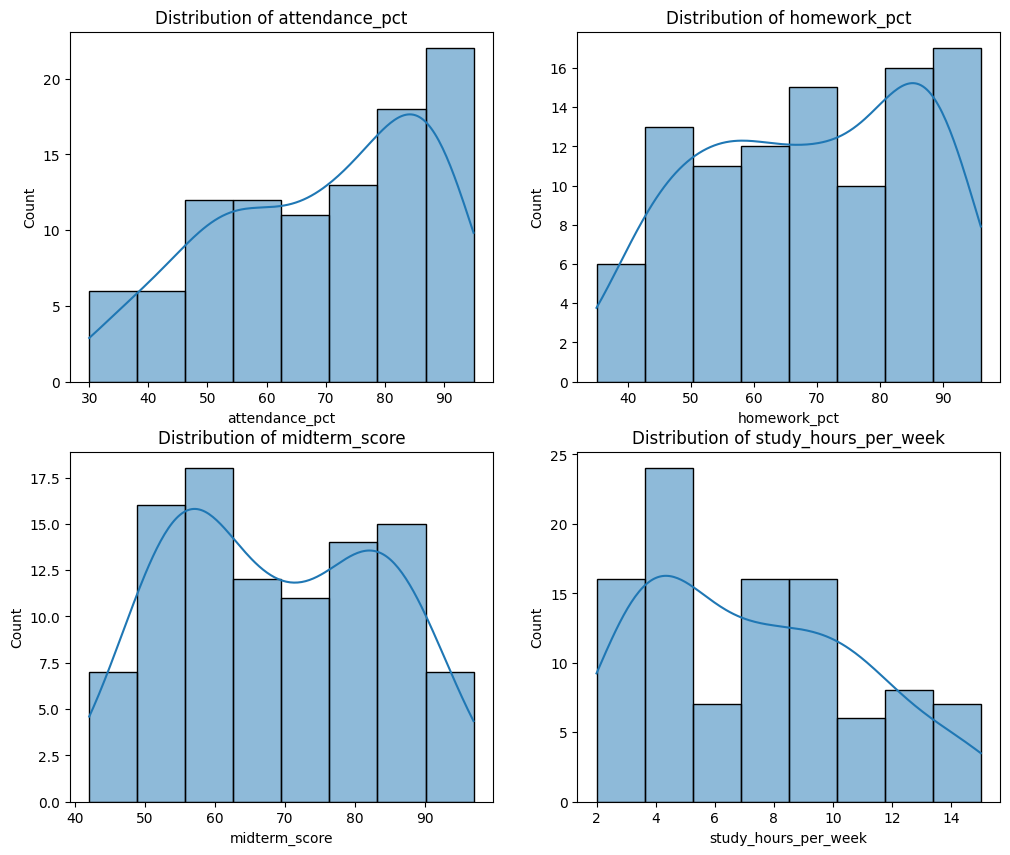

In [5]:
numerical_cols = ['attendance_pct', 'homework_pct', 'midterm_score', 'study_hours_per_week']

fig, axs = plt.subplots(2, 2, figsize=(12, 10))

for ax, col in zip(axs.ravel(), numerical_cols):
    sns.histplot(data[col], kde=True, ax=ax)
    ax.set_title(f'Distribution of {col}')

La distribución de las características numéricas varian entre si. Para "attendance_pct" la distribución esta ligeramente sesgada a la derecha, mostrando una mayor cantidad de valores altos. Esto se puede interpretar a que los estudiantes assiten regularmente. "homework_pct" se puede ver una distribución uniforme, con una acumulación mayor en valores altos."midterm_score" se concentran en un rango de valores con mayor cantidad. "study_hours_per_week" se ve que la mayoría de estudiantes estudian una poca cantidad de horas por semana. Se debe aplicar técnicas de escalamiento para asegurar que las característicass estan en escalas similares.

# **Visualización de Características Categoricas**

En este caso este dataset no tiene otras características categoricas a parte de "pass" pero esa es la característica objetivo.

# **Distribución de la Característica Objetivo**

Ahora se visualiza la distribución de la característica objetivo "pass" para ver el balance de clase en el dataset.

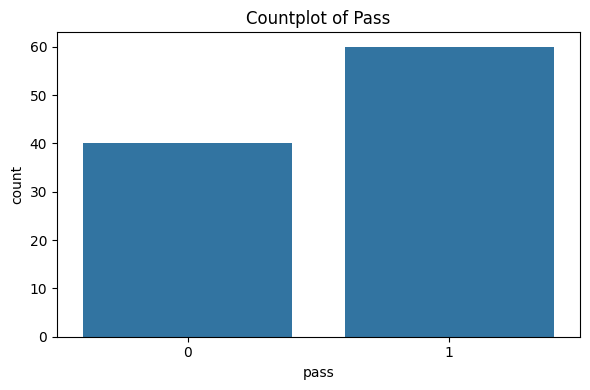

In [6]:
fig = plt.figure(figsize=(6, 4))
sns.countplot(data=data, x='pass')
plt.title('Countplot of Pass')
plt.tight_layout()

Aquí se tiene la distribución de las características numéricas para los que aprobaron y los que reprobaron. Comparando el conteo del pasar/reprobar con el resto de las características.

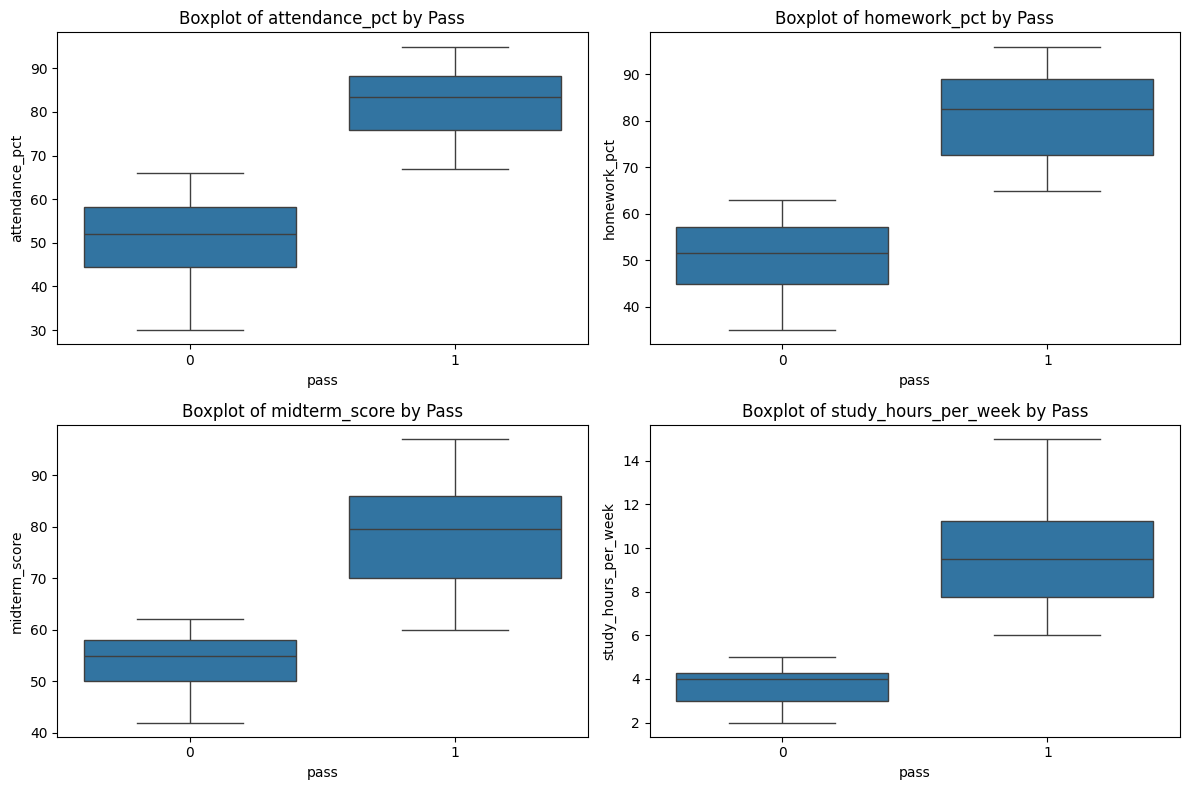

In [7]:
fig, axs = plt.subplots(2, 2, figsize=(12, 8))

for ax, col in zip(axs.ravel(), numerical_cols):
    sns.boxplot(data=data, x='pass', y=col, ax=ax)
    ax.set_title(f'Boxplot of {col} by Pass')

fig.tight_layout()

Se puede ver una gran diferencia en las distribuciones de las características numéricas entre los que pasaron o reprobaron la clase. Para cada característica se puede ver que los que pasaron la clase asistieron con mayor frecuencia la clase, sacaron mejor calificación en las tareas, les fue mejor en el examen y estudiaron más que los otros cada semana. Por lo que un alto valor en cada característica hace más probable que el alumno haya pasado.

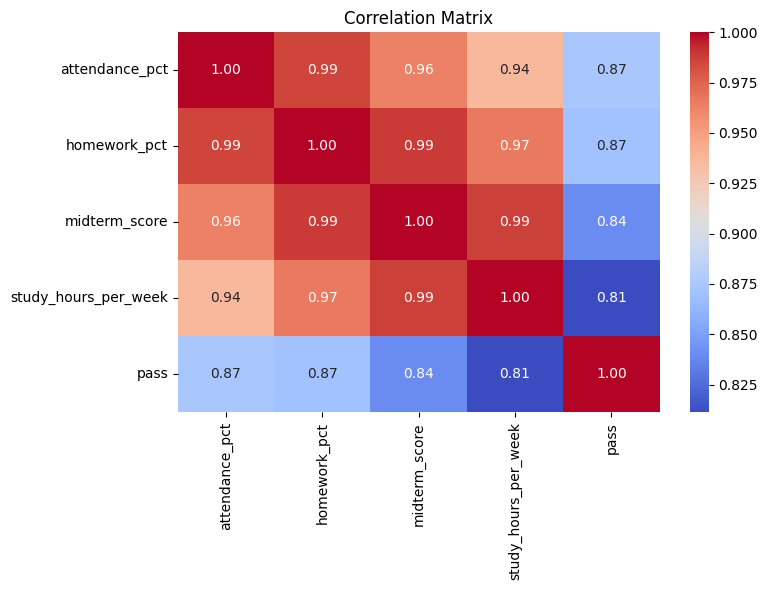

In [8]:
corr_matrix = data[['attendance_pct', 'homework_pct', 'midterm_score', 'study_hours_per_week', 'pass']].corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.tight_layout()

Con la matriz de correlación se puede ver la correlación entre columnas numéricas, donde como afecta cada característica al resultado final del objetivo. Aquí el porcentaje de asistencia y la calificación de tareas tienen la mayor correlación con "pass".

# **Manejar Datos Faltantes**

En el caso de este dataset, no hubo ningún dato faltante en alguna columna, por lo que no se tiene que utilizar alguna técnica para esta situación.

# **Preprocesamiento de Pipelines**

En el preprocesamiento se realizan transformaciones a las características numéricas. En este caso solo se le aplican escalamiento estandar para que todas las columnas esten en la misma escala, de manera en que ninguna domine a las demás solo por su magnitud que pueda ser mayor a las demás. Se realiza ya que no miden lo mismo y sus rangos varian entre ellas, si se siguiera como estan los datos entonces las horas de estudio quedarían opacadas debido a que tiene valores/rango menor a las otras, así estas columnas son comparables.

In [9]:
preprocessing_pipeline = make_pipeline(
    ColumnTransformer(
        transformers=[
            (
                'num',
                make_pipeline(StandardScaler()),
                ['attendance_pct', 'homework_pct', 'midterm_score', 'study_hours_per_week']
            )
        ],
        remainder='passthrough',
    )
)

Para la matriz de las características solo se tienen en cuenta las numéricas debido a que no se encontraron características categoricas relevantes. Mientras que y son los datos de los que pasaron o no la clase. En este caso la división del dataset para el entrenamiento y el testeo es de 80-20, que para este dataset se traduce en que 80 de la entradas/registros son parte del entrenamiento, mientras que el resto (20 registros) son utilizadas para testear el modelo entrenado y los resultados que pueda dar. Dando un total de 100 registros totales del dataset.

In [19]:
x = data[numerical_cols]
y = data['pass']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

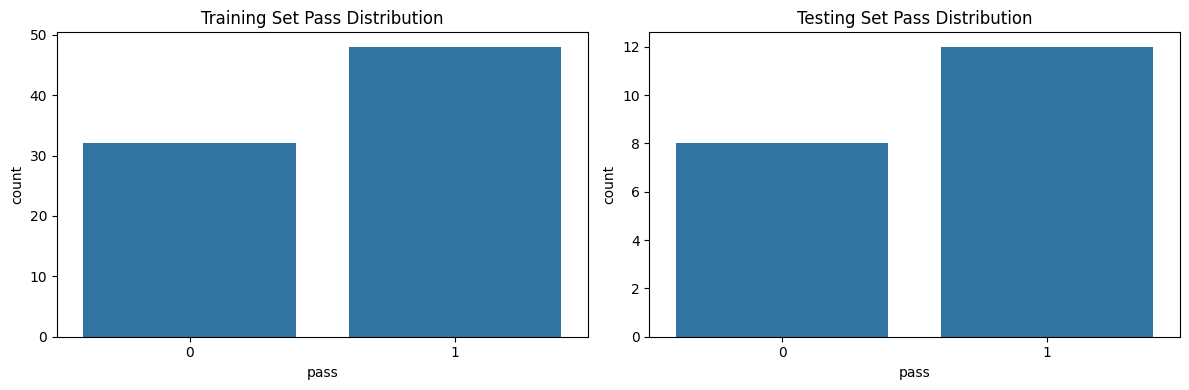

In [20]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(x=y_train, ax=axs[0])
axs[0].set_title('Training Set Pass Distribution')
sns.countplot(x=y_test, ax=axs[1])
axs[1].set_title('Testing Set Pass Distribution')
fig.tight_layout()

Aquí se llama fit_transform para acomodar el pipeline y transformar los datos. Mientras que para testing se llama transform. Llamar fit o fit_transform en los datos de testeo puede llevar a data leakage. Por lo que es importante separar el uso de estas funciones.

In [21]:
x_train_processed = preprocessing_pipeline.fit_transform(x_train, y_train)
x_train_processed

array([[-4.95262082e-01, -5.49759889e-01, -7.44818128e-01,
        -6.46847948e-01],
       [ 1.20277934e+00,  1.15537773e+00,  1.22326622e+00,
         1.30065125e+00],
       [ 4.10360011e-01,  2.14612149e-01,  1.37426579e-01,
         1.87794566e-01],
       [ 6.36765534e-01,  1.03778204e+00,  1.08753626e+00,
         7.44222908e-01],
       [ 1.41503452e-02, -7.93770963e-02, -2.01898308e-01,
        -9.04196057e-02],
       [-1.96689798e+00, -1.72571687e+00, -1.42346790e+00,
        -1.48149046e+00],
       [-3.82059321e-01, -4.32164191e-01, -6.76953150e-01,
        -6.46847948e-01],
       [ 1.14617796e+00,  1.09657989e+00,  1.01967129e+00,
         1.02243708e+00],
       [-4.95262082e-01, -6.08557738e-01, -8.12683105e-01,
        -9.25062120e-01],
       [ 1.83954488e-01,  9.70164510e-02,  1.69662444e-03,
        -9.04196057e-02],
       [-2.12255178e-01, -3.73366342e-01, -5.41223195e-01,
        -6.46847948e-01],
       [ 1.20277934e+00,  1.15537773e+00,  1.08753626e+00,
      

In [22]:
x_test_processed = preprocessing_pipeline.transform(x_test)
x_test_processed

array([[ 1.20277934e+00,  1.21417558e+00,  1.29113120e+00,
         1.30065125e+00],
       [-4.24510356e-02, -1.96972795e-01, -3.37628263e-01,
        -3.68633777e-01],
       [ 1.03297520e+00,  9.20186339e-01,  6.80346399e-01,
         7.44222908e-01],
       [-1.55653797e-01, -2.55770644e-01, -4.05493240e-01,
        -3.68633777e-01],
       [-7.78268986e-01, -6.67355587e-01, -6.09088173e-01,
        -6.46847948e-01],
       [-8.34870367e-01, -7.84951286e-01, -7.44818128e-01,
        -6.46847948e-01],
       [-6.65066225e-01, -8.43749135e-01, -8.12683105e-01,
        -9.25062120e-01],
       [ 2.40555868e-01,  1.55814300e-01,  1.69662444e-03,
        -9.04196057e-02],
       [-1.34428279e+00, -1.02014268e+00, -1.01627804e+00,
        -1.20327629e+00],
       [-1.17447865e+00, -1.37292978e+00, -1.21987297e+00,
        -1.20327629e+00],
       [-1.11787727e+00, -1.31413193e+00, -1.15200799e+00,
        -9.25062120e-01],
       [ 2.40555868e-01,  3.82186019e-02, -6.61683530e-02,
      

# **Construir un Modelo de Clasificación**

In [23]:
classification_model = make_pipeline(
    preprocessing_pipeline,
    LogisticRegression()
)

In [24]:
classification_model

Pipeline(steps=[('pipeline',
                 Pipeline(steps=[('columntransformer',
                                  ColumnTransformer(remainder='passthrough',
                                                    transformers=[('num',
                                                                   Pipeline(steps=[('standardscaler',
                                                                                    StandardScaler())]),
                                                                   ['attendance_pct',
                                                                    'homework_pct',
                                                                    'midterm_score',
                                                                    'study_hours_per_week'])]))])),
                ('logisticregression', LogisticRegression())])

In [25]:
classification_model.fit(x_train, y_train)

Pipeline(steps=[('pipeline',
                 Pipeline(steps=[('columntransformer',
                                  ColumnTransformer(remainder='passthrough',
                                                    transformers=[('num',
                                                                   Pipeline(steps=[('standardscaler',
                                                                                    StandardScaler())]),
                                                                   ['attendance_pct',
                                                                    'homework_pct',
                                                                    'midterm_score',
                                                                    'study_hours_per_week'])]))])),
                ('logisticregression', LogisticRegression())])

In [26]:
y_test_pred = classification_model.predict(x_test)
y_test_pred

array([1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1])

In [27]:
x_test['Pass_Predicted'] = y_test_pred
x_test['Pass_Actual'] = y_test.values
x_test

,attendance_pct,homework_pct,midterm_score,study_hours_per_week,Pass_Predicted,Pass_Actual
98,91,90,88,12,1,1
39,69,66,64,6,1,1
1,88,85,79,10,1,1
28,67,65,63,6,1,1
37,56,58,60,5,0,0
97,55,56,58,5,0,0
20,58,55,57,4,0,0
63,74,72,69,7,1,1
47,46,52,54,3,0,0
56,49,46,51,3,0,0


En este dataset, que "pass" sea 1 significa que el alumno paso la clase, cero es que reprobo la clase. En este caso al comparar el rendimiento del modelo, se puede ver que en todas las ocasiones el valor a predecir fue el mismo que el valor actual.